In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from matplotlib.patches import Rectangle

In [2]:
def calculate_heat_tendency(ds, ds1):
    """
    Calculate the components of the local temperature tendency equation.

    Parameters
    ----------
    ds : xarray.Dataset
        Atmospheric dataset containing the variables:
        - lon : longitude
        - lat : latitude
        - t   : temperature [K]
        - u   : zonal wind [m s-1]
        - v   : meridional wind [m s-1]
        - w   : vertical velocity [m s-1]
        - p   : pressure [Pa]
        - time: time coordinate

        The calculation uses the first three vertical levels:
        level 0 = bottom
        level 1 = middle
        level 2 = top

    ds_sfc : xarray.DataArray
        Surface pressure used to calculate potential temperature.

    Returns
    -------
    out : xarray.Dataset
        Dataset containing:

        adv_h : horizontal temperature advection [K s-1]
        adv_v : vertical temperature advection [K s-1]
        Q     : residual temperature tendency [K s-1]
        dT_dt : local temperature tendency [K s-1]

    Notes
    -----
    Horizontal advection is calculated as:

        Adv = -(U dT/dx + V dT/dy)

    Vertical advection is calculated using:

        VAdv = -W * (T/T) * dT/dp

    The local temperature tendency is calculated using the temporal
    derivative of the middle-level temperature:

        dT_dt = dT/dt

    The residual is calculated as:

        Q = dT_dt - Adv - VAdv
    """

    # --------------------------------------------------
    # Get dimensions
    # --------------------------------------------------

    lons = ds['longitude'][:]
    lats = ds['latitude'][:]

    # --------------------------------------------------
    # Calculate distances of the grid points in m
    # --------------------------------------------------

    lons_g, lats_g = np.meshgrid(lons, lats)

    Xdist_arr = (
        np.diff(lons_g * np.pi * 6371000 / 180)
        * np.cos(lats_g[:, :-1] * np.pi / 180)
    )

    Ydist_arr = (
        np.diff(lats_g, axis=0)
        * np.pi * 6371000 / 180
    )

    # --------------------------------------------------
    # Get variables
    # --------------------------------------------------

    Tbot = ds1['t'][:, 0, :, :] - 273.15
    Tmed = ds['t'][:, 1, :, :] - 273.15
    Ttop = ds1['t'][:, 1, :, :] - 273.15

    Umed = ds['u'][:, 1, :, :]
    Vmed = ds['v'][:, 1, :, :]
    Wmed = ds['w'][:, 1, :, :]

    # --------------------------------------------------
    # Advection in horizontal axis
    # --------------------------------------------------

    dT_dx = (
        (
            np.diff(Tmed, axis=2)[:, :, :-1]
            +
            np.diff(Tmed, axis=2)[:, :, 1:]
        )
        / 2
        / (2 * Xdist_arr[:, :-1])
    )

    dT_dy = (
        (
            np.diff(Tmed, axis=1)[:, :-1, :]
            +
            np.diff(Tmed, axis=1)[:, 1:, :]
        )
        / 2
        / (2 * Ydist_arr[:-1, :])
    )

    Adv = -(
        Umed[:, 1:-1, 1:-1] * dT_dx[:, 1:-1, :]
        +
        Vmed[:, 1:-1, 1:-1] * dT_dy[:, :, 1:-1]
    )

    # --------------------------------------------------
    # Advection in vertical axis
    # --------------------------------------------------


    Tpotbot = (
        (Tbot + 273.15)
        * (1000 / 750) ** 0.286
    )

    Tpotmed = (
        (Tmed + 273.15)
        * (1000 / 700) ** 0.286
    )

    Tpottop = (
        (Ttop + 273.15)
        * (1000 / 650) ** 0.286
    )

    dTpot_dp = (
        (Tpotbot - Tpottop)
        / (75000 - 65000)
    )

    VAdv = -(
        Wmed[:, 1:-1, 1:-1]
        * (Tmed[:,1:-1,1:-1]+273.15)/Tpotmed[:,1:-1,1:-1] 
        * dTpot_dp[:, 1:-1, 1:-1]
    )

    # --------------------------------------------------
    # Local tendency
    # --------------------------------------------------

    time_seconds = (
        ds.time.values
        .astype("datetime64[s]")
        .astype(np.int64)
    )

    t_numeric = Tmed.assign_coords(
        time=time_seconds
    )

    dT_dt = t_numeric.differentiate("time")

    dT_dt = dT_dt.assign_coords(
        time=ds.time
    )

    # --------------------------------------------------
    # Temperature tendency / residual
    # --------------------------------------------------

    Res = dT_dt - Adv - VAdv

    # --------------------------------------------------
    # Output
    # --------------------------------------------------

    out = xr.Dataset()

    out["adv_h"] = Adv * 3600 * 24
    out["adv_v"] = VAdv * 3600 * 24
    out["residual"] = Res * 3600 * 24
    out["tendency"] = dT_dt * 3600 * 24
    out["t700"] = Tmed

    # --------------------------------------------------
    # Units
    # --------------------------------------------------

    out["adv_h"].attrs["units"] = "°C day-1"
    out["adv_v"].attrs["units"] = "°C day-1"
    out["residual"].attrs["units"] = "°C day-1"
    out["tendency"].attrs["units"] = "°C day-1"
    out["t700"].attrs["units"] = "°C"

    return out

In [3]:
filename = "/home/lacrio/DATA/term_cal/data_700/era5_t_uvw_20210204_20210214.nc"

ds = xr.open_dataset(filename).rename({"valid_time": "time"}) 


filename = "/home/lacrio/DATA/term_cal/data_750_650/era5_t_uvw_20210204_20210214.nc"

ds1 = xr.open_dataset(filename).rename({"valid_time": "time"})
ds1.pressure_level

<xarray.DataArray 'pressure_level' (pressure_level: 2)> Size: 16B
array([750., 650.])
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 16B 750.0 650.0
Attributes:
    long_name:         pressure
    units:             hPa
    positive:          down
    stored_direction:  decreasing
    standard_name:     air_pressure

In [4]:
ds_cal = calculate_heat_tendency(ds, ds1).resample(time='1d').mean()  

In [5]:
ds_cal

<xarray.Dataset> Size: 6MB
Dimensions:         (time: 11, latitude: 111, longitude: 179)
Coordinates:
  * latitude        (latitude) float64 888B -42.25 -42.5 -42.75 ... -69.5 -69.75
  * longitude       (longitude) float64 1kB -84.75 -84.5 -84.25 ... -40.5 -40.25
    number          int64 8B 0
    pressure_level  float64 8B 750.0
  * time            (time) datetime64[ns] 88B 2021-02-04 ... 2021-02-14
Data variables:
    adv_h           (time, latitude, longitude) float64 2MB -0.1849 ... -0.9023
    adv_v           (time, latitude, longitude) float32 874kB 1.251 ... 0.9062
    residual        (time, latitude, longitude) float64 2MB -0.6632 ... -2.317
    tendency        (time, latitude, longitude) float32 874kB 0.259 ... -2.476
    t700            (time, latitude, longitude) float32 874kB 9.382 ... -12.59

In [6]:
def thermo_weighted_table(
    ds,
    lat_min=-70, lat_max=-62,
    lon_min=-76, lon_max=-55
):
    """
    Compute area-weighted thermodynamic budget over a region
    and return a pandas DataFrame.
    """

    # --------------------------------------------
    # COORDENADAS
    # --------------------------------------------
    lons = ds['longitude'].values
    lats = ds['latitude'].values
    times = ds['time'].values

    lon2d, lat2d = np.meshgrid(lons, lats)

    # --------------------------------------------
    # PESOS (cos(lat))
    # --------------------------------------------
    weights = np.sqrt(np.cos(np.deg2rad(lat2d)))

    # --------------------------------------------
    # MÁSCARA ESPACIAL
    # --------------------------------------------
    mask = (
        (lat2d >= lat_min) & (lat2d <= lat_max) &
        (lon2d >= lon_min) & (lon2d <= lon_max)
    )

    weights_masked = np.where(mask, weights, 0)

    # normalización (muy importante)
    wsum = np.sum(weights_masked)

    # --------------------------------------------
    # VARIABLES
    # --------------------------------------------
    Adv  = ds['adv_h'].values
    VAdv = ds['adv_v'].values
    Res  = ds['residual'].values
    Tend = ds['tendency'].values
    T    = ds['t700'].values

    # --------------------------------------------
    # PROMEDIOS ESPACIALES
    # --------------------------------------------
    def wmean(var):
        return np.sum(var * weights_masked, axis=(1,2)) / wsum

    Adv_m  = wmean(Adv)
    VAdv_m = wmean(VAdv)
    Res_m  = wmean(Res)
    Tend_m = wmean(Tend)
    T_m    = wmean(T)

    # --------------------------------------------
    # DATAFRAME (TABLA)
    # --------------------------------------------
    df = pd.DataFrame({
        "time": times[:-1],
        "tendency": Tend_m[:-1],
        "adv_h": Adv_m[:-1],
        "adv_v": VAdv_m[:-1],
        "residual": Res_m[:-1],
        "t700": T_m[1:] #np.append(T_m[1:], np.nan)
    })

    df = df.set_index("time")

    return df


In [7]:
df_PIs = thermo_weighted_table(ds_cal, lat_min=-52.5, lat_max=-45, lon_min=-74.5, lon_max=-72)
df_APIS = thermo_weighted_table(ds_cal, lat_min=-69, lat_max=-62, lon_min=-72, lon_max=-55)

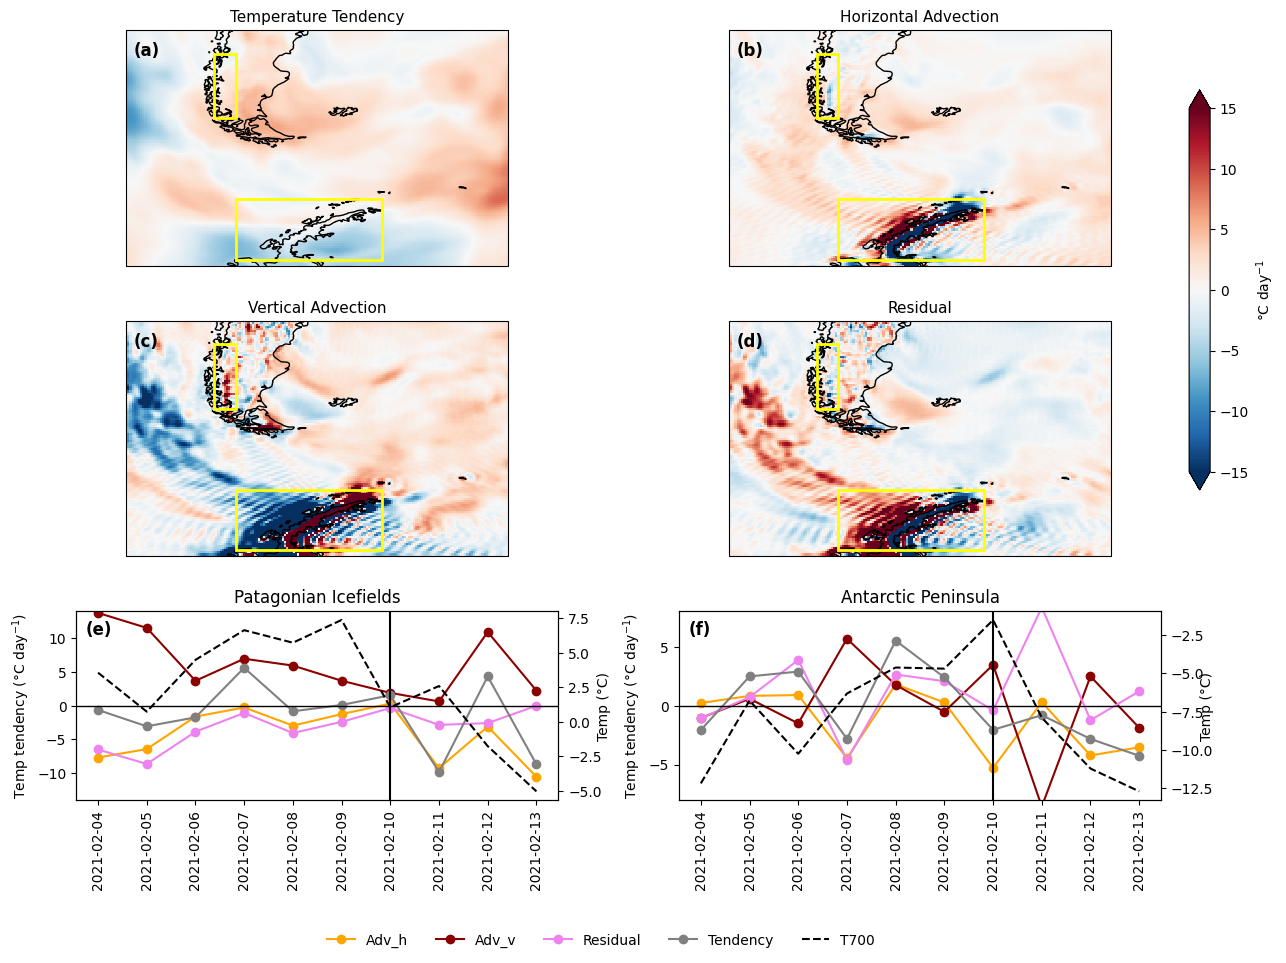

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

# ============================================
# SELECT TIME
# ============================================
time_sel = '2021-02-10'
ds_sel = ds_cal.sel(time=time_sel)

event_date = np.datetime64("2021-02-10")

# ============================================
# FIGURE + GRID (BALANCED)
# ============================================
fig = plt.figure(figsize=(14, 10))

gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[1, 1, 0.8],   # 🔥 mejor proporción
    hspace=0.25,
    wspace=0.25
)

plt.subplots_adjust(right=0.9)  # espacio para colorbar

# ============================================
# MAPS (a–d)
# ============================================
axes_map = [
    fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,1], projection=ccrs.PlateCarree()),
]

vars_plot = ["tendency", "adv_h", "adv_v", "residual"]

titles = [
    "Temperature Tendency",
    "Horizontal Advection",
    "Vertical Advection",
    "Residual"
]

lon = ds_sel.longitude
lat = ds_sel.latitude

vmax = 15
vmin = -vmax

for i, ax in enumerate(axes_map):

    im = ax.pcolormesh(
        lon,
        lat,
        ds_sel[vars_plot[i]],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution="50m")

    ax.set_extent([
        float(lon.min()), float(lon.max()),
        float(lat.min())+1.5, float(lat.max())
    ])

    ax.set_title(titles[i], fontsize=11)

    ax.text(
        0.02, 0.95,
        f"({chr(97+i)})",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top"
    )

    boxes = [
        {'bbox': [float(-74.5), float(-72.0), # lon
                  float(-52.5), float(-45.0),], 'color': 'yellow'},  # lat # Patagonia Ice
        {'bbox': [float(-72), float(-55),
                  float(-69), float(-62),], 'color': 'yellow'},]
    for b in boxes:
        x0, x1, y0, y1 = b['bbox']
        rect = Rectangle((x0, y0), x1 - x0, y1 - y0,
                        edgecolor=b['color'], facecolor='none', lw=2,
                        transform=ccrs.PlateCarree(), zorder=10)
        ax.add_patch(rect)

# ============================================
# COLORBAR (INDEPENDENT)
# ============================================
cax = fig.add_axes([0.92, 0.42, 0.015, 0.4])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation='vertical',
    extend='both'
)

cbar.set_label("°C day$^{-1}$")

# ============================================
# TIME SERIES (e–f)
# ============================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[2, 0])
ax1b = ax1.twinx()

t = df_PIs.index

l1, = ax1.plot(t, df_PIs["adv_h"], 'o-', color='orange')
l2, = ax1.plot(t, df_PIs["adv_v"], 'o-', color='darkred')
l3, = ax1.plot(t, df_PIs["residual"], 'o-', color='violet')
l4, = ax1.plot(t, df_PIs["tendency"], 'o-', color='gray')
l5, = ax1b.plot(t, df_PIs["t700"], '--', color='k')

ax1.axhline(0, color='k', linewidth=1)
ax1.axvline(event_date, color='k', linestyle='-')

ax1.set_ylim(-14, 14)
ax1.set_title("Patagonian Icefields")

ax1.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax1b.set_ylabel('Temp (°C)')

# mover eje derecho
ax1b.yaxis.set_label_coords(1.08, 0.5)

ax1.text(0.02, 0.95, "(e)", transform=ax1.transAxes,
         fontsize=12, fontweight="bold", va="top")


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[2, 1])
ax2b = ax2.twinx()

t = df_APIS.index

ax2.plot(t, df_APIS["adv_h"], 'o-', color='orange')
ax2.plot(t, df_APIS["adv_v"], 'o-', color='darkred')
ax2.plot(t, df_APIS["residual"], 'o-', color='violet')
ax2.plot(t, df_APIS["tendency"], 'o-', color='gray')
ax2b.plot(t, df_APIS["t700"], '--', color='k')

ax2.axhline(0, color='k', linewidth=1)
ax2.axvline(event_date, color='k', linestyle='-')

ax2.set_ylim(-8, 8)
ax2.set_title("Antarctic Peninsula")

# evitar duplicación
ax2.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax2b.set_ylabel('Temp (°C)')
ax2b.yaxis.set_label_coords(1.08, 0.5)

ax2.text(0.02, 0.95, "(f)", transform=ax2.transAxes,
         fontsize=12, fontweight="bold", va="top")

# ============================================
# LEGEND (SOLO TIME SERIES, CENTRADA)
# ============================================
fig.legend(
    [l1, l2, l3, l4, l5],
    ['Adv_h', 'Adv_v', 'Residual', 'Tendency', 'T700'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    frameon=False,
    fontsize=10
)

# ============================================
# FORMAT
# ============================================
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=90)

fig.savefig(
    "./fig/temp_tendency_sergi_2021_f.png",
    dpi=300,
    bbox_inches="tight"
)


In [9]:
df_PIs

,tendency,adv_h,adv_v,residual,t700
time,,,,,
2021-02-04,-0.637360,-7.702185,13.774729,-6.506590,3.553031
2021-02-05,-3.070925,-6.447012,11.549126,-8.660231,0.733371
2021-02-06,-1.739437,-1.621631,3.689607,-3.867014,4.480243
2021-02-07,5.621646,-0.270131,6.966297,-1.079368,6.629920
2021-02-08,-0.836918,-2.960254,5.952325,-4.065827,5.721451
2021-02-09,0.101557,-1.255865,3.703424,-2.403737,7.370405
2021-02-10,1.549611,0.304313,1.895051,-0.352389,1.049464
2021-02-11,-9.850663,-9.275798,0.628702,-2.851034,2.587452
2021-02-12,4.343558,-3.112542,10.942684,-2.593023,-1.764748


In [10]:
df_APIS

,tendency,adv_h,adv_v,residual,t700
time,,,,,
2021-02-04,-2.070254,0.227879,-1.051347,-1.063725,-12.170648
2021-02-05,2.481776,0.829229,0.589354,0.719523,-6.772063
2021-02-06,2.892735,0.899639,-1.505506,3.879689,-10.240342
2021-02-07,-2.814879,-4.450490,5.679056,-4.609486,-6.314981
2021-02-08,5.522107,1.809701,1.753216,2.643490,-4.621468
2021-02-09,2.393607,0.273848,-0.523695,2.074623,-4.693112
2021-02-10,-2.049123,-5.276308,3.471833,-0.396654,-1.521343
2021-02-11,-0.806691,0.288087,-8.562217,8.334568,-7.887867
2021-02-12,-2.823318,-4.221726,2.486514,-1.231846,-11.203279
